In [1]:
import random 
from random import sample, seed, shuffle
import numpy as np
import pandas as pd
import os
import six
from rdkit import rdBase
from rdkit import RDLogger

# Suppress RDKit warnings
rdBase.DisableLog('rdApp.*')
RDLogger.DisableLog('rdApp.*')

#utility functions : prepare the data 
from model_fp_selection.lib.utils import prepare_df_morgan, prepare_df_rdkit, swap_identical_ligands, prepare_df_chemeleon
from model_fp_selection.lib.utils import drop_duplicates, average_duplicates

#utility functions : CV and results 
from model_fp_selection.lib.utils import obtain_metrics, plot_cv_results
from model_fp_selection.lib.utils import df_split, get_indices, get_indices_doi, get_indices_scaff
from model_fp_selection.lib.utils import generate_scaffold, scaffold_to_smiles
from model_fp_selection.lib.utils import ligands_permutation, cross_validation, prepare_train_set


from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, Draw
from rdkit.ML.Descriptors.MoleculeDescriptors import MolecularDescriptorCalculator
from sklearn.model_selection import KFold, GridSearchCV, cross_val_score, GroupKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, median_absolute_error, PredictionErrorDisplay
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.preprocessing import MinMaxScaler

#Encoding categorical Data
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Regressors
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor

#Pipelines and other model constructions
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer

# Visualization
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20})

#np.random.seed(42)
#seed(42)

#Specific to Scaffold Splitting
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict
import pickle as pkl
import time
from tqdm import tqdm
import seaborn as sns

from itertools import *

C:\Users\bparm\anaconda3\envs\chemeleon_ruthenium_complexes\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
metals = pd.read_csv("ruthenium_complexes_dataset.csv", dtype={'L1': str, 'L2': str, 'L3': str})

In [3]:
#metals = prepare_df_morgan(metals, 2, 1024)

In [4]:
#metals = average_duplicates(metals, 'Ligands_Tuple', 'pIC50')

In [5]:
l=len(metals)
metals_chemeleon_1 = prepare_df_chemeleon(metals[0:int(0.33*l)])

In [6]:
metals_chemeleon_2 = prepare_df_chemeleon(metals[int(0.33*l):int(0.66*l)])

In [7]:
metals_chemeleon_3 = prepare_df_chemeleon(metals[int(0.66*l):l])


In [8]:
metals_chemeleon = pd.concat([metals_chemeleon_1, metals_chemeleon_2, metals_chemeleon_3], ignore_index=True)
metals_chemeleon = average_duplicates(metals_chemeleon, 'Ligands_Tuple', 'pIC50')

Length of training dataset after cleaning duplicates, before adding permutations : 715


# Training the model

Bayesian Optimisation allowed us to get the best hyperparameters for the random forest model, depending on the Fingerprint used.

In [9]:
rf_chemeleon = RandomForestRegressor(max_depth=25, n_estimators=380, min_samples_leaf=1, max_features=0.4, random_state=42, n_jobs=16)

### Random Splitting

#### On the whole dataset, Chemeleon fingerprints

In [10]:
X = np.array(metals_chemeleon['Descriptors'].values.tolist())
y = np.array(metals_chemeleon['pIC50'].values.tolist())

indices_chemeleon = get_indices(metals_chemeleon, CV=10, shuffle=True)

train length : 643 | test length : 72
train length : 643 | test length : 72
train length : 643 | test length : 72
train length : 643 | test length : 72
train length : 643 | test length : 72
train length : 644 | test length : 71
train length : 644 | test length : 71
train length : 644 | test length : 71
train length : 644 | test length : 71
train length : 644 | test length : 71


In [11]:
y_data_chemeleon, y_predictions_chemeleon = cross_validation(metals_chemeleon, indices_chemeleon, X, y, rf_chemeleon, descriptors=True)

CV iteration 0
CV iteration 1
CV iteration 2
CV iteration 3
CV iteration 4
CV iteration 5
CV iteration 6
CV iteration 7
CV iteration 8
CV iteration 9
{'MAE': 0.3511369886190769, 'RMSE': 0.4709820578358029, 'Ratio': 1.3413057385040608, 'R² Score': 0.6799230922119672}


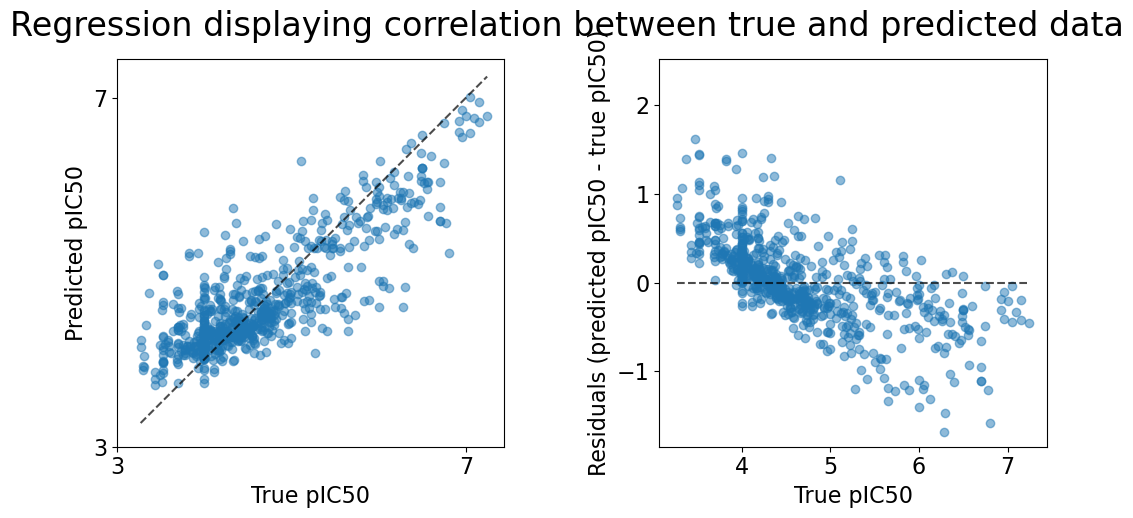

In [19]:
plot_cv_results(y_data_chemeleon, y_predictions_chemeleon, log=True)

In [20]:
chemeleon_fp = pd.DataFrame()
chemeleon_fp['data'] = y_data_chemeleon
chemeleon_fp['predictions'] = y_predictions_chemeleon
s=[]
for i in range(10):
    s=s+indices_chemeleon[i][1].tolist()
chemeleon_fp['indices'] = s

chemeleon_fp=chemeleon_fp.sort_values(by='indices')

In [21]:
chemeleon_fp.to_csv('chemeleon_fp_permut_AAB_new_HP.csv')

In [18]:
X_train, y_train, X_test = prepare_train_set(metals_chemeleon, range(643), range(643,715), permutation=True)

In [19]:
len(X_train)

1992

### HeLa cells

In [10]:
metals_chemeleon_hela = metals_chemeleon[metals_chemeleon['Cells'] == 'HeLa']
metals_chemeleon_hela.reset_index(drop=True, inplace=True)

X_hela = np.array(metals_chemeleon_hela['Descriptors'].values.tolist())
y_hela = np.array(metals_chemeleon_hela['pIC50'].values.tolist())

indices_chemeleon_hela = get_indices(metals_chemeleon_hela, CV=10, shuffle=True)

train length : 156 | test length : 18
train length : 156 | test length : 18
train length : 156 | test length : 18
train length : 156 | test length : 18
train length : 157 | test length : 17
train length : 157 | test length : 17
train length : 157 | test length : 17
train length : 157 | test length : 17
train length : 157 | test length : 17
train length : 157 | test length : 17


In [11]:
y_data_chemeleon_hela, y_predictions_chemeleon_hela = cross_validation(metals_chemeleon_hela, indices_chemeleon_hela, 
                                                                       X_hela, y_hela, rf_chemeleon)


CV iteration 0
CV iteration 1
CV iteration 2
CV iteration 3
CV iteration 4
CV iteration 5
CV iteration 6
CV iteration 7
CV iteration 8
CV iteration 9
{'MAE': 0.2948622809705302, 'RMSE': 0.407636708722855, 'Ratio': 1.382464747207175, 'R² Score': 0.4316350633852889}


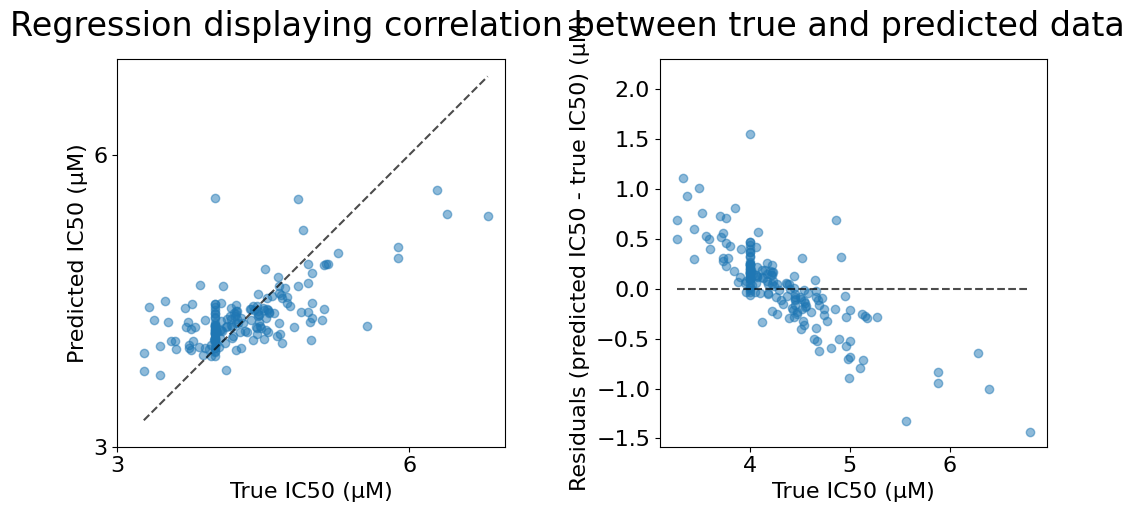

In [12]:
plot_cv_results(y_data_chemeleon_hela, y_predictions_chemeleon_hela)

## DOI Splitting

#### On the whole dataset, Chemeleon fingerprints

In [13]:
X_chemeleon_doi = np.array(metals_chemeleon['Descriptors'].values.tolist())
y_chemeleon_doi = np.array(metals_chemeleon['pIC50'].values.tolist())

indices_chemeleon_doi = get_indices_doi(metals_chemeleon, CV=10)

fold 0 groups: train 196 test 21
fold 0 train set : 643 | test set : 72
fold 1 groups: train 196 test 21
fold 1 train set : 643 | test set : 72
fold 2 groups: train 195 test 22
fold 2 train set : 643 | test set : 72
fold 3 groups: train 195 test 22
fold 3 train set : 643 | test set : 72
fold 4 groups: train 195 test 22
fold 4 train set : 643 | test set : 72
fold 5 groups: train 196 test 21
fold 5 train set : 644 | test set : 71
fold 6 groups: train 195 test 22
fold 6 train set : 644 | test set : 71
fold 7 groups: train 195 test 22
fold 7 train set : 644 | test set : 71
fold 8 groups: train 195 test 22
fold 8 train set : 644 | test set : 71
fold 9 groups: train 195 test 22
fold 9 train set : 644 | test set : 71


In [14]:
y_data_chemeleon_doi, y_predictions_chemeleon_doi = cross_validation(metals_chemeleon,
                                                                 indices_chemeleon_doi, X_chemeleon_doi,
                                                                 y_chemeleon_doi, rf_chemeleon, descriptors=True)

CV iteration 0
CV iteration 1
CV iteration 2
CV iteration 3
CV iteration 4
CV iteration 5
CV iteration 6
CV iteration 7
CV iteration 8
CV iteration 9
{'MAE': 0.5008362584300763, 'RMSE': 0.6550863468486693, 'Ratio': 1.3079850666205879, 'R² Score': 0.3807832251339204}


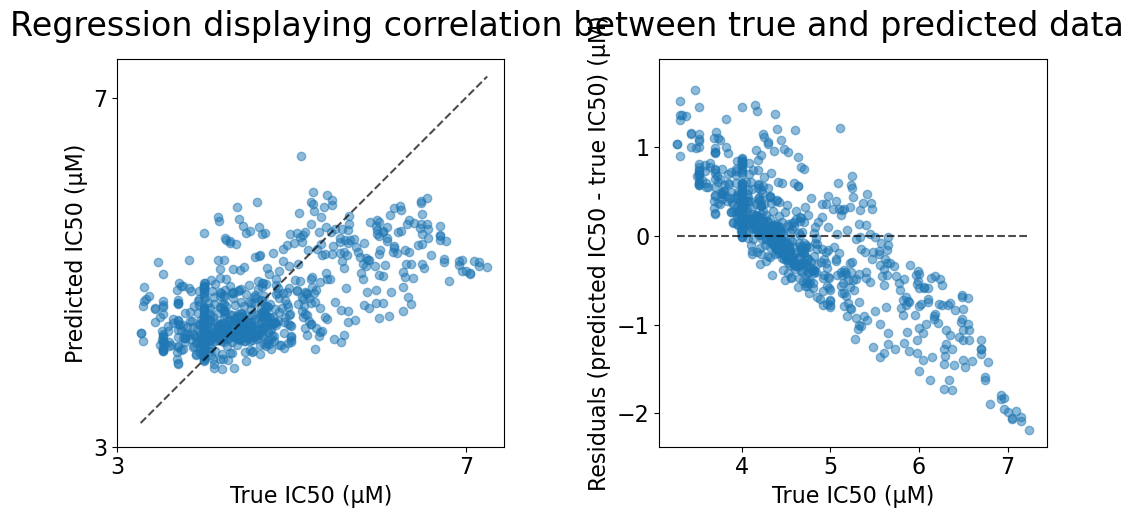

In [15]:
plot_cv_results(y_data_chemeleon_doi, y_predictions_chemeleon_doi)

In [23]:
chemeleon_fp_doi = pd.DataFrame()
chemeleon_fp_doi['data'] = y_data_chemeleon_doi
chemeleon_fp_doi['predictions'] = y_predictions_chemeleon_doi
s=[]
for i in range(10):
    s=s+indices_chemeleon_doi[i][1]
chemeleon_fp_doi['indices'] = s

chemeleon_fp_doi=chemeleon_fp_doi.sort_values(by='indices')
chemeleon_fp_doi.to_csv('chemeleon_fp_doi_permut_AAB_rand_new_HP.csv')

## Scaffold Splitting

#### Scaffold for ligand A, Chemeleon fingerprints

In [16]:
metals_A = metals_chemeleon.copy()
metals_A.reset_index(drop=True, inplace=True)

X_A = np.array(metals_A['Descriptors'].values.tolist())
y_A = np.array(metals_A['pIC50'].values.tolist())

# We must extract the mol objects as the get_indices_scaff take a list of mol objects as argument, not a dataframe
molsA = metals_A['MOL1'].tolist()

indicesA = get_indices_scaff(molsA, CV=10)

100%|██████████████████████████████████████████████████████████████████████████████| 679/679 [00:00<00:00, 1959.77it/s]

train length : 608 | test length : 71
train length : 665 | test length : 14
train length : 476 | test length : 203
train length : 378 | test length : 301
train length : 670 | test length : 9
train length : 645 | test length : 34
train length : 665 | test length : 14
train length : 664 | test length : 15
train length : 671 | test length : 8
train length : 669 | test length : 10


In [17]:
y_dataA, y_predictionsA = cross_validation(metals_A, indicesA, X_A, y_A, rf_chemeleon)

CV iteration 0
CV iteration 1


KeyboardInterrupt: 

In [ ]:
plot_cv_results(y_dataA, y_predictionsA)

#### Scaffold for ligand B, Chemeleon fingerprints

In [16]:
metals_B = metals_chemeleon.copy()
metals_B.reset_index(drop=True, inplace=True)
#metals_B['MOL3'] = metals_B['L3'].apply(Chem.MolFromSmiles)

X_B = np.array(metals_B['Descriptors'].values.tolist())
y_B = np.array(metals_B['pIC50'].values.tolist())

# We must extract the mol objects as the get_indices_scaff take a list of mol objects as argument, not a dataframe
molsB = metals_B['MOL3'].tolist()

indicesB = get_indices_scaff(molsB, CV=10)

100%|██████████████████████████████████████████████████████████████████████████████| 715/715 [00:00<00:00, 1811.67it/s]

train length : 669 | test length : 46
train length : 647 | test length : 68
train length : 670 | test length : 45
train length : 572 | test length : 143
train length : 676 | test length : 39
train length : 663 | test length : 52
train length : 656 | test length : 59
train length : 569 | test length : 146
train length : 665 | test length : 50
train length : 648 | test length : 67


In [17]:
y_dataB, y_predictionsB = cross_validation(metals_B, indicesB, X_B, y_B, rf_chemeleon, descriptors=True)

CV iteration 0
CV iteration 1
CV iteration 2
CV iteration 3
CV iteration 4
CV iteration 5
CV iteration 6
CV iteration 7
CV iteration 8
CV iteration 9
{'MAE': 0.46222499218704904, 'RMSE': 0.6082405617096102, 'Ratio': 1.3158971755977074, 'R² Score': 0.4661781155790484}


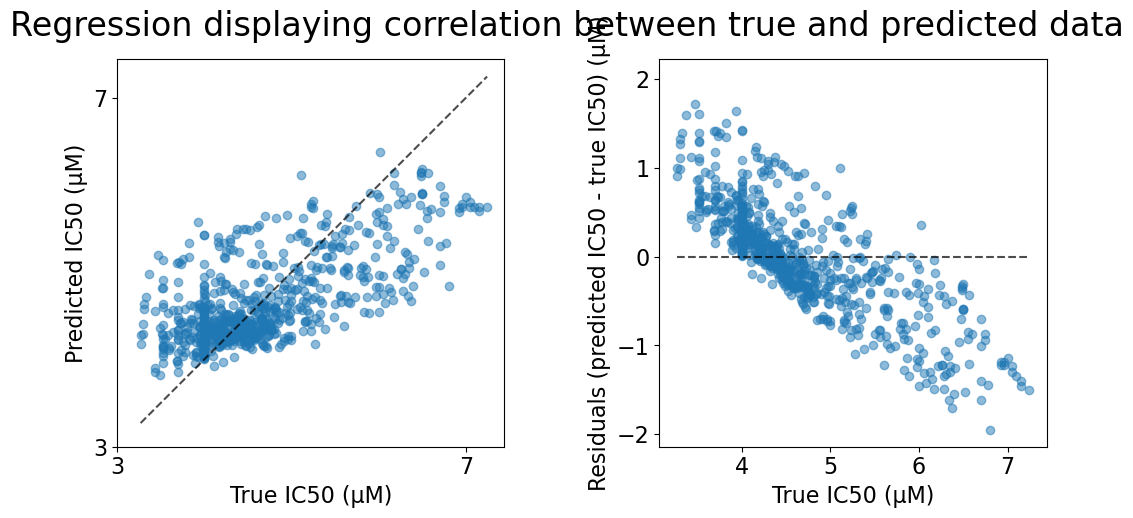

In [18]:
plot_cv_results(y_dataB, y_predictionsB)

In [24]:
chemeleon_fp_B = pd.DataFrame()
chemeleon_fp_B['data'] = y_dataB
chemeleon_fp_B['predictions'] = y_predictionsB
s=[]
for i in range(10):
    s=s+indicesB[i][1]
chemeleon_fp_B['indices'] = s

chemeleon_fp_B=chemeleon_fp_B.sort_values(by='indices')
chemeleon_fp_B.to_csv('chemeleon_fp_B_permut_200scaff_AAB_new_HP.csv')